# Introduction

<center><img src="https://i.imgur.com/9hLRsjZ.jpg" height=400></center>

This dataset was scraped from [nextspaceflight.com](https://nextspaceflight.com/launches/past/?page=1) and includes all the space missions since the beginning of Space Race between the USA and the Soviet Union in 1957!

### Import Statements

In [86]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# These might be helpful:
from iso3166 import countries
from datetime import datetime, timedelta

### Notebook Presentation

In [87]:
pd.options.display.float_format = '{:,.2f}'.format

### Load the Data

In [88]:
df_data = pd.read_csv('mission_launches.csv')

# Preliminary Data Exploration

* What is the shape of `df_data`? 
* How many rows and columns does it have?
* What are the column names?
* Are there any NaN values or duplicates?

In [90]:
df_data.shape
df_data.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'Organisation', 'Location', 'Date',
       'Detail', 'Rocket_Status', 'Price', 'Mission_Status'],
      dtype='object')

In [91]:
df_data.isnull().any()

Unnamed: 0.1      False
Unnamed: 0        False
Organisation      False
Location          False
Date              False
Detail            False
Rocket_Status     False
Price              True
Mission_Status    False
dtype: bool

<p>How many nan values in respective column?</p>

In [92]:
df_data.isnull().sum()

Unnamed: 0.1         0
Unnamed: 0           0
Organisation         0
Location             0
Date                 0
Detail               0
Rocket_Status        0
Price             3360
Mission_Status       0
dtype: int64

In [93]:
df_data.head()

,Unnamed: 0.1,Unnamed: 0,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
0,0,0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success
1,1,1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
2,2,2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success
3,3,3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success
4,4,4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.0,Success


## Data Cleaning - Check for Missing Values and Duplicates

Consider removing columns containing junk data. 

In [94]:
# print(df_data.duplicated().sum())
# print(f"Missing values {df_data.isnull().sum()}")
print(df_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4324 entries, 0 to 4323
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Unnamed: 0.1    4324 non-null   int64 
 1   Unnamed: 0      4324 non-null   int64 
 2   Organisation    4324 non-null   object
 3   Location        4324 non-null   object
 4   Date            4324 non-null   object
 5   Detail          4324 non-null   object
 6   Rocket_Status   4324 non-null   object
 7   Price           964 non-null    object
 8   Mission_Status  4324 non-null   object
dtypes: int64(2), object(7)
memory usage: 304.2+ KB
None


In [95]:
def parse_dates(date_str):
    date_format = [
        "%a %b %d, %Y %H:%M %Z",
        "%a %b %d, %Y"
    ]

    for fmt in date_format:
        try:
            return pd.to_datetime(date_str, format=fmt, utc=True)
        except ValueError:
            continue
    return pd.NaT


In [96]:
# print("Is Null Values:\n", df_data.isnull().sum())
# print("Duplicates", df_data.duplicated().sum())

cleaned_df = df_data.drop(columns=['Unnamed: 0', 'Unnamed: 0.1'])
cleaned_df["Date"] = cleaned_df["Date"].apply(parse_dates)

cleaned_df["Price"] = pd.to_numeric(cleaned_df["Price"], errors='coerce').astype("float64")
cleaned_df["Price"] = cleaned_df["Price"].fillna(0).astype("float64")

cleaned_df = cleaned_df.drop_duplicates()
# print("Duplicates", cleaned_df.duplicated().sum())

print(cleaned_df.info())
# print(f"Missing values {cleaned_df.isnull().sum()}")

<class 'pandas.core.frame.DataFrame'>
Index: 4323 entries, 0 to 4323
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype              
---  ------          --------------  -----              
 0   Organisation    4323 non-null   object             
 1   Location        4323 non-null   object             
 2   Date            4323 non-null   datetime64[ns, UTC]
 3   Detail          4323 non-null   object             
 4   Rocket_Status   4323 non-null   object             
 5   Price           4323 non-null   float64            
 6   Mission_Status  4323 non-null   object             
dtypes: datetime64[ns, UTC](1), float64(1), object(5)
memory usage: 270.2+ KB
None


## Descriptive Statistics

In [97]:
cleaned_df.describe()

,Price
count,"4,323.00"
mean,28.49
std,85.94
min,0.00
25%,0.00
50%,0.00
75%,0.00
max,450.00


In [98]:
cleaned_df.head()

,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA",2020-08-07 05:12:00+00:00,Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.00,Success
1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...",2020-08-06 04:01:00+00:00,Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
2,SpaceX,"Pad A, Boca Chica, Texas, USA",2020-08-04 23:57:00+00:00,Starship Prototype | 150 Meter Hop,StatusActive,0.00,Success
3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan",2020-07-30 21:25:00+00:00,Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.00,Success
4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA",2020-07-30 11:50:00+00:00,Atlas V 541 | Perseverance,StatusActive,145.00,Success


# Number of Launches per Company

Create a chart that shows the number of space mission launches by organisation.

In [99]:
no_of_launches = cleaned_df['Organisation'].value_counts()
no_of_launches.columns = ['Organisation', 'No of Launches']
print(no_of_launches)

Organisation
RVSN USSR           1777
Arianespace          279
General Dynamics     251
CASC                 250
NASA                 203
VKS RF               201
US Air Force         161
ULA                  140
Boeing               136
Martin Marietta      114
SpaceX               100
MHI                   84
Northrop              83
Lockheed              79
ISRO                  76
Roscosmos             55
ILS                   46
Sea Launch            36
ISAS                  30
Kosmotras             22
US Navy               17
Rocket Lab            13
ISA                   13
Eurockot              13
ESA                   13
Blue Origin           12
IAI                   11
ExPace                10
ASI                    9
CNES                   8
AMBA                   8
JAXA                   7
Land Launch            7
MITT                   7
UT                     5
CASIC                  5
KCST                   5
Exos                   4
CECLES                 4
Arm??e de l'

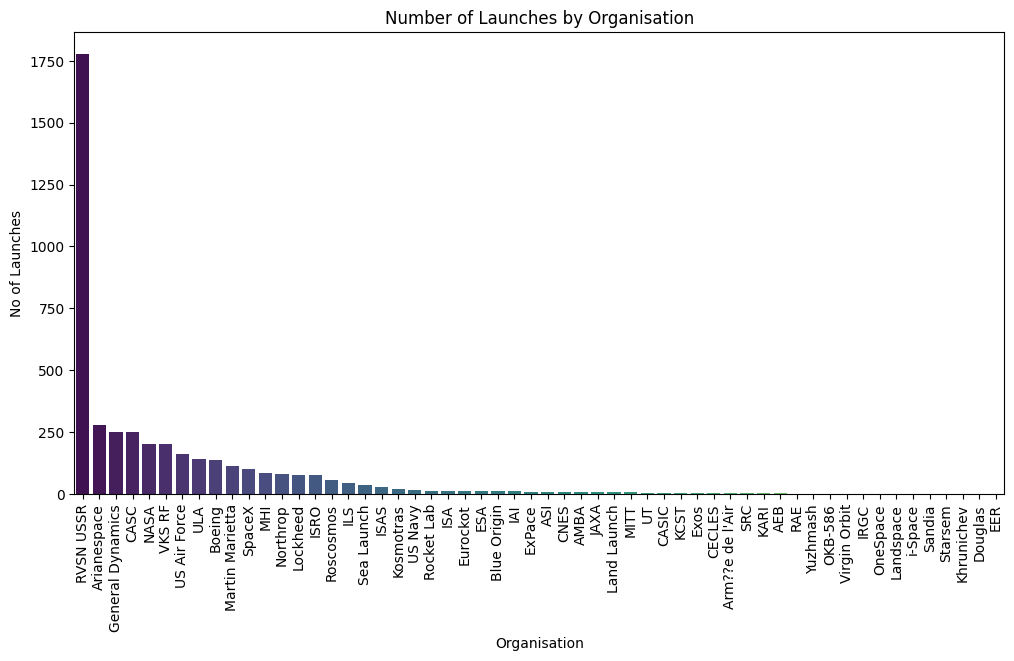

In [100]:
plt.figure(figsize=(12, 6))
sns.barplot(
    x=no_of_launches.index,
    y=no_of_launches.values,
    palette='viridis',
    hue=no_of_launches.index,
    legend=False
)
plt.xticks(rotation=90)
plt.xlabel('Organisation')
plt.ylabel('No of Launches')
plt.title('Number of Launches by Organisation')
plt.show()

# Number of Active versus Retired Rockets

How many rockets are active compared to those that are decomissioned? 

In [101]:
status_counts = cleaned_df['Rocket_Status'].value_counts()
print(status_counts)

Rocket_Status
StatusRetired    3534
StatusActive      789
Name: count, dtype: int64


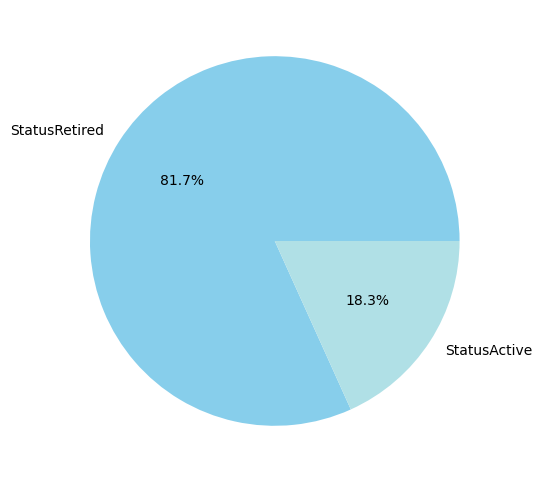

In [102]:
plt.figure(figsize=(6, 6))
plt.pie(
    status_counts,
    labels=status_counts.index,
    autopct='%1.1f%%',
    colors=['skyblue', 'powderblue']
)
plt.show()

# Distribution of Mission Status

How many missions were successful?
How many missions failed?

In [103]:
mission_status = cleaned_df['Mission_Status'].value_counts()
print(mission_status)

Mission_Status
Success              3878
Failure               339
Partial Failure       102
Prelaunch Failure       4
Name: count, dtype: int64


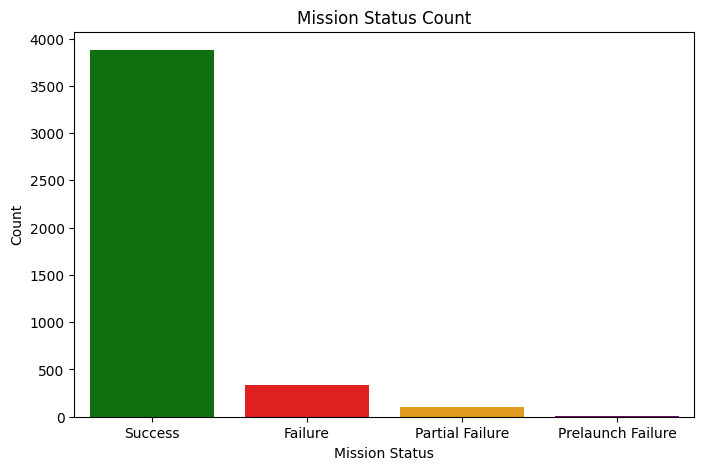

In [104]:
plt.figure(figsize=(8, 5))
sns.barplot(
    x=mission_status.index,
    y=mission_status.values,
    palette=['green', 'red', 'orange', 'purple'],
    hue=mission_status.index,
    legend=False
)
plt.xlabel('Mission Status')
plt.ylabel('Count')
plt.title('Mission Status Count')
plt.xticks(rotation=0)
plt.show()

# How Expensive are the Launches? 

Create a histogram and visualise the distribution. The price column is given in USD millions (careful of missing values). 

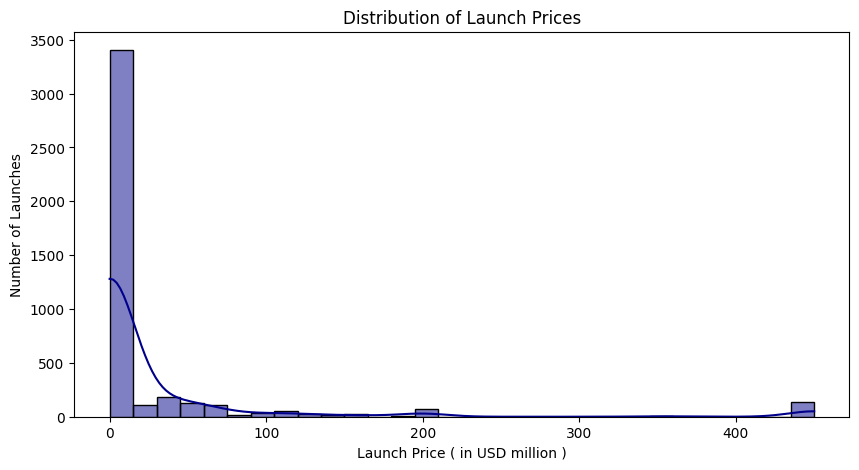

In [105]:
plt.figure(figsize=(10, 5))
sns.histplot(
    cleaned_df['Price'],
    bins=30,
    kde=True,
    color='darkblue'
)
plt.xlabel("Launch Price ( in USD million )")
plt.ylabel("Number of Launches")
plt.title("Distribution of Launch Prices")

plt.show()

In [106]:
cleaned_df.head()

,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA",2020-08-07 05:12:00+00:00,Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.00,Success
1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...",2020-08-06 04:01:00+00:00,Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
2,SpaceX,"Pad A, Boca Chica, Texas, USA",2020-08-04 23:57:00+00:00,Starship Prototype | 150 Meter Hop,StatusActive,0.00,Success
3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan",2020-07-30 21:25:00+00:00,Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.00,Success
4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA",2020-07-30 11:50:00+00:00,Atlas V 541 | Perseverance,StatusActive,145.00,Success


# Use a Choropleth Map to Show the Number of Launches by Country

* Create a choropleth map using [the plotly documentation](https://plotly.com/python/choropleth-maps/)
* Experiment with [plotly's available colours](https://plotly.com/python/builtin-colorscales/). I quite like the sequential colour `matter` on this map. 
* You'll need to extract a `country` feature as well as change the country names that no longer exist.

Wrangle the Country Names

You'll need to use a 3 letter country code for each country. You might have to change some country names.

* Russia is the Russian Federation
* New Mexico should be USA
* Yellow Sea refers to China
* Shahrud Missile Test Site should be Iran
* Pacific Missile Range Facility should be USA
* Barents Sea should be Russian Federation
* Gran Canaria should be USA


You can use the iso3166 package to convert the country names to Alpha3 format.

In [107]:
def get_alpha3(country_names):

    # MANUAL CORRECTION FOR SPECIFIC COUNTRIES NAME
    custom_mapping = {
        "Russia": "RUS",
        "New Mexico": "USA",
        "Yellow Sea": "CHN",
        "Shahrud Missile Test Site": "IRN",
        "Pacific Missile Range Facility": "USA",
        "Barents Sea": "RUS",
        "Gran Canaria": "USA"
    }

    country_names = country_names.split(",")[-1].strip()

    if country_names in custom_mapping:
        return custom_mapping[country_names]
    
    try:
        return countries.get(country_names).alpha3
    except KeyError:
        return "Unknown"


In [108]:
cleaned_df["Country_Alpha3"] = cleaned_df["Location"].apply(get_alpha3)
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4323 entries, 0 to 4323
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype              
---  ------          --------------  -----              
 0   Organisation    4323 non-null   object             
 1   Location        4323 non-null   object             
 2   Date            4323 non-null   datetime64[ns, UTC]
 3   Detail          4323 non-null   object             
 4   Rocket_Status   4323 non-null   object             
 5   Price           4323 non-null   float64            
 6   Mission_Status  4323 non-null   object             
 7   Country_Alpha3  4323 non-null   object             
dtypes: datetime64[ns, UTC](1), float64(1), object(6)
memory usage: 304.0+ KB


# Use a Choropleth Map to Show the Number of Failures by Country


In [109]:
failure_df = cleaned_df[cleaned_df["Mission_Status"] == "Failure"]
failure_by_country = failure_df["Country_Alpha3"].value_counts().reset_index()
failure_by_country.head()

,Country_Alpha3,count
0,USA,129
1,KAZ,72
2,RUS,63
3,CHN,19
4,Unknown,16


In [110]:
fig = px.choropleth(
    failure_by_country,
    locations="Country_Alpha3",
    locationmode="ISO-3",
    color="count",
    color_continuous_scale="Reds",
    title="Rocket Launch Failures by Country"
)
fig.update_layout(margin={"r":0,"t":100,"l":0,"b":100})
fig.show()

# Create a Plotly Sunburst Chart of the countries, organisations, and mission status. 

In [111]:
fig = px.sunburst(
    cleaned_df,
    path=['Country_Alpha3', 'Organisation', 'Mission_Status'],
    title="Rocket Launches by Country, Organisation and Mission Status",
    color="Mission_Status",
    color_discrete_map={'Success': 'green', 'Failure': 'red', 'Partial Failure': 'orange', 'Prelaunch Failure': 'purple'}
)
fig.update_layout(width=900, height=700)
fig.show()

# Analyse the Total Amount of Money Spent by Organisation on Space Missions

In [112]:
total_spending = cleaned_df.groupby('Organisation')['Price'].sum().sort_values(ascending=False).reset_index()
total_spending.head()

,Organisation,Price
0,NASA,"61,200.00"
1,Arianespace,"16,345.00"
2,ULA,"14,798.00"
3,CASC,"6,310.51"
4,SpaceX,"5,444.00"


In [113]:
fig = px.bar(
    total_spending,
    x="Organisation",
    y="Price",
    title="Total Amount Spent by Organisation On Space Missions",
    labels={"Price": "Total Amount Spent ( in USD million )"},
    color="Price",
    color_continuous_scale="Viridis"
)
fig.show()

# Analyse the Amount of Money Spent by Organisation per Launch

In [114]:
spending_per_launch = cleaned_df.groupby("Organisation").agg(
    Total_Spending=("Price", "sum"),
    Launch_Count=("Organisation", "count")
)
spending_per_launch.head()

,Total_Spending,Launch_Count
Organisation,,
AEB,0.00,3
AMBA,0.00,8
ASI,0.00,9
Arianespace,"16,345.00",279
Arm??e de l'Air,0.00,4


In [115]:
spending_per_launch["Avg_cost_per_launch"] = spending_per_launch["Total_Spending"] / spending_per_launch["Launch_Count"]
spending_per_launch = spending_per_launch.sort_values(by="Avg_cost_per_launch", ascending=False).reset_index()
spending_per_launch.head()

,Organisation,Total_Spending,Launch_Count,Avg_cost_per_launch
0,NASA,"61,200.00",203,301.48
1,ULA,"14,798.00",140,105.70
2,Arianespace,"16,345.00",279,58.58
3,SpaceX,"5,444.00",100,54.44
4,Northrop,"3,930.00",83,47.35


In [116]:

fig = px.bar(
    spending_per_launch,
    x="Organisation",
    y="Avg_cost_per_launch",
    title="Average Cost Per Launch by Organisation",
    labels={"Avg_cost_per_launch": "Avg Cost per Launch (in USD Millions)"},
    color="Avg_cost_per_launch",
    color_continuous_scale="burgyl"
)

fig.show()

# Chart the Number of Launches per Year

In [117]:
cleaned_df['Year'] = cleaned_df["Date"].dt.year
launched_per_year = cleaned_df["Year"].value_counts().sort_index()
launched_per_year.head()

Year
1957     3
1958    28
1959    20
1960    39
1961    52
Name: count, dtype: int64

In [118]:
fig = px.line(
    x=launched_per_year.index,
    y=launched_per_year.values,
    title="Number of Space Launches per Year",
    labels={"x": "Year", "y": "Number of Launches"},
    markers=True
)

fig.show()

# Chart the Number of Launches Month-on-Month until the Present

Which month has seen the highest number of launches in all time? Superimpose a rolling average on the month on month time series chart. 

In [119]:
cleaned_df["Date"] = cleaned_df["Date"].dt.tz_localize(None)
cleaned_df["Year-Month"] = cleaned_df["Date"].dt.to_period("M")
monthly_launches = cleaned_df["Year-Month"].value_counts().sort_index().reset_index()
monthly_launches.columns = ["Year-Month", "Launches"]
monthly_launches["Year-Month"] = monthly_launches["Year-Month"].astype(str)
monthly_launches["Rolling-Avg"] = monthly_launches["Launches"].rolling(window=3, min_periods=1).mean()
monthly_launches.head()

busiest_month = monthly_launches.loc[monthly_launches["Launches"].idxmax()]
print(f"The busiest month ever was {busiest_month['Year-Month']} with {busiest_month['Launches']} launches.")

The busiest month ever was 1971-12 with 18 launches.


In [120]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=monthly_launches["Year-Month"],
    y=monthly_launches["Launches"],
    mode="lines+markers",
    name="Monthly Launches",
    line=dict(color="royalblue")
))

fig.add_trace(go.Scatter(
    x=monthly_launches["Year-Month"],
    y=monthly_launches["Rolling-Avg"],
    mode="lines",
    name="3-Monthly Rolling-Avg",
    line=dict(color="red", dash="dash")
))

fig.update_layout(
    title="Month-on-Month Space Launches",
    xaxis_title="Year-Month",
    yaxis_title="No of Launches",
    hovermode="x unified"
)

fig.show()

# Launches per Month: Which months are most popular and least popular for launches?

Some months have better weather than others. Which time of year seems to be best for space missions?

In [121]:
cleaned_df["Month"] = cleaned_df["Date"].dt.month
cleaned_df["Month_Name"] = cleaned_df["Date"].dt.strftime("%B")

In [122]:
launches_per_month = cleaned_df["Month_Name"].value_counts().reindex(
    ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]
)

launches_per_month.head()

Month_Name
January     268
February    336
March       353
April       383
May         326
Name: count, dtype: int64

In [123]:
fig = px.bar(
    x=launches_per_month.index,
    y=launches_per_month.values,
    title="Most & Least Popular Months for Space Launches",
    labels={"x": "Month", "y": "No of Launches"},
    color=launches_per_month.values,
    color_continuous_scale="sunsetdark"
)

fig.update_layout(
    xaxis=dict(tickmode="array", tickvals=list(range(1, 13))),
    xaxis_title="Month",
    yaxis_title="No of Launches"
)

fig.show()

# How has the Launch Price varied Over Time? 

Create a line chart that shows the average price of rocket launches over time. 

In [124]:
avg_price_per_year = cleaned_df.groupby("Year")["Price"].mean().reset_index()
avg_price_per_year.head()

,Year,Price
0,1957,0.00
1,1958,0.00
2,1959,0.00
3,1960,0.00
4,1961,0.00


In [125]:
fig = px.line(
    avg_price_per_year,
    x="Year",
    y="Price",
    title="Average Rocket Launch Price Over Time",
    labels={"Year": "Launch Year", "Price": "Avg Price ( in USD million )"},
    markers=True
)

fig.update_layout(
    xaxis=dict(dtick=1),
    yaxis_title="Avg Price ( in USD million )"
)

fig.show()

# Chart the Number of Launches over Time by the Top 10 Organisations. 

How has the dominance of launches changed over time between the different players? 

In [126]:
top_10_orgs = cleaned_df["Organisation"].value_counts().nlargest(10).index
print(top_10_orgs)
df_10_orgs = cleaned_df[cleaned_df["Organisation"].isin(top_10_orgs)]
df_10_orgs.head()

Index(['RVSN USSR', 'Arianespace', 'General Dynamics', 'CASC', 'NASA',
       'VKS RF', 'US Air Force', 'ULA', 'Boeing', 'Martin Marietta'],
      dtype='object', name='Organisation')


,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status,Country_Alpha3,Year,Year-Month,Month,Month_Name
1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...",2020-08-06 04:01:00,Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success,CHN,2020,2020-08,8,August
4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA",2020-07-30 11:50:00,Atlas V 541 | Perseverance,StatusActive,145.00,Success,USA,2020,2020-07,7,July
5,CASC,"LC-9, Taiyuan Satellite Launch Center, China",2020-07-25 03:13:00,"Long March 4B | Ziyuan-3 03, Apocalypse-10 & N...",StatusActive,64.68,Success,CHN,2020,2020-07,7,July
7,CASC,"LC-101, Wenchang Satellite Launch Center, China",2020-07-23 04:41:00,Long March 5 | Tianwen-1,StatusActive,0.00,Success,CHN,2020,2020-07,7,July
12,CASC,"LC-3, Xichang Satellite Launch Center, China",2020-07-09 12:11:00,Long March 3B/E | Apstar-6D,StatusActive,29.15,Success,CHN,2020,2020-07,7,July


In [127]:
top_10_launches_per_year = df_10_orgs.groupby(["Organisation", "Year"]).size().reset_index(name="Launches")
top_10_launches_per_year

,Organisation,Year,Launches
0,Arianespace,1984,3
1,Arianespace,1985,4
2,Arianespace,1986,3
3,Arianespace,1987,2
4,Arianespace,1988,6
...,...,...,...
318,VKS RF,2016,4
319,VKS RF,2017,6
320,VKS RF,2018,5
321,VKS RF,2019,8


In [128]:
fig = px.line(
    top_10_launches_per_year,
    x="Year",
    y="Launches",
    color="Organisation",
    title="Top 10 Organisations Space Launches Over Time",
    labels={"Year": "Launch Year", "Launches": "Number of Launches"},
    markers=True
)

fig.update_layout(
    xaxis=dict(dtick=1),
    yaxis_title="Number of Launches",
    legend_title="Organisation"
)

fig.show()

# Cold War Space Race: USA vs USSR

The cold war lasted from the start of the dataset up until 1991. 

In [129]:
df_cold_war = cleaned_df[cleaned_df["Year"] <= 1991]
df_cold_war.head()

,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status,Country_Alpha3,Year,Year-Month,Month,Month_Name
1717,CASC,"LC-3, Xichang Satellite Launch Center, China",1991-12-28 12:00:00,Long March 3 | DFH-2A-T5,StatusRetired,0.00,Partial Failure,CHN,1991,1991-12,12,December
1718,RVSN USSR,"Site 175/58, Baikonur Cosmodrome, Kazakhstan",1991-12-20 00:00:00,Rokot/Briz K | GVM Demo Flight,StatusRetired,0.00,Success,KAZ,1991,1991-12,12,December
1719,Yuzhmash,"Site 32/2, Plesetsk Cosmodrome, Russia",1991-12-18 03:54:00,Tsyklon-3 | Intercosmos 25 & Magion 3,StatusRetired,0.00,Success,RUS,1991,1991-12,12,December
1720,Arianespace,"ELA-2, Guiana Space Centre, French Guiana, France",1991-12-16 22:19:00,"Ariane 44L | Telecom 2A, Inmarsat 2F3",StatusRetired,0.00,Success,FRA,1991,1991-12,12,December
1721,General Dynamics,"SLC-36B, Cape Canaveral AFS, Florida, USA",1991-12-07 22:47:00,Atlas II | Eutelsat 2F3,StatusRetired,0.00,Success,USA,1991,1991-12,12,December


In [130]:
usa_keywords = ["USA", "United States", "NASA", "Kennedy Space Center"]
ussr_keywords = ["USSR", "Soviet", "Baikonur", "Russia", "Kazakhstan", "Roscosmos", "Kosmotras", "Eurockot", "VKS RF"]

def classify_superpower(location):
    if any(keyword in location for keyword in usa_keywords):
        return "USA"
    elif any(keyword in location for keyword in ussr_keywords):
        return "USSR"
    else:
        return "Others"

df_cold_war["Superpower"] = df_cold_war["Location"].apply(classify_superpower)

df_cold_war = df_cold_war[df_cold_war["Superpower"].isin(["USA", "USSR"])]
df_cold_war.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2432 entries, 1718 to 4323
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Organisation    2432 non-null   object        
 1   Location        2432 non-null   object        
 2   Date            2432 non-null   datetime64[ns]
 3   Detail          2432 non-null   object        
 4   Rocket_Status   2432 non-null   object        
 5   Price           2432 non-null   float64       
 6   Mission_Status  2432 non-null   object        
 7   Country_Alpha3  2432 non-null   object        
 8   Year            2432 non-null   int32         
 9   Year-Month      2432 non-null   period[M]     
 10  Month           2432 non-null   int32         
 11  Month_Name      2432 non-null   object        
 12  Superpower      2432 non-null   object        
dtypes: datetime64[ns](1), float64(1), int32(2), object(8), period[M](1)
memory usage: 247.0+ KB


/tmp/ipykernel_30758/3884507488.py:12: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



## Create a Plotly Pie Chart comparing the total number of launches of the USSR and the USA

Hint: Remember to include former Soviet Republics like Kazakhstan when analysing the total number of launches. 

In [131]:
tot_launches_cold_war = df_cold_war["Superpower"].value_counts().reset_index()
tot_launches_cold_war.columns = ["Superpower", "Launches"]
print(tot_launches_cold_war[tot_launches_cold_war["Superpower"] == "USSR"])

  Superpower  Launches
0       USSR      1770


In [133]:
fig = px.pie(
    tot_launches_cold_war,
    names="Superpower",
    values="Launches",
    title="Total Space Launches: USA vs USSR ( Cold War Era )",
    color="Superpower",
    color_discrete_map={"USA": "grey", "USSR": "black"}
)

fig.update_traces(
    textinfo="percent+label",
    pull=[0.05, 0]
)

fig.show()

## Create a Chart that Shows the Total Number of Launches Year-On-Year by the Two Superpowers

## Chart the Total Number of Mission Failures Year on Year.

## Chart the Percentage of Failures over Time

Did failures go up or down over time? Did the countries get better at minimising risk and improving their chances of success over time? 

# For Every Year Show which Country was in the Lead in terms of Total Number of Launches up to and including including 2020)

Do the results change if we only look at the number of successful launches? 

# Create a Year-on-Year Chart Showing the Organisation Doing the Most Number of Launches

Which organisation was dominant in the 1970s and 1980s? Which organisation was dominant in 2018, 2019 and 2020? 